In [1]:
import pandas as pd
df=pd.read_excel("SuperStore_Sales_Dataset.xlsx")
df.head()

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Profit,Returns,Payment Mode,Profit Ratio,Year,Month,Column1,Unnamed: 25
0,4918,CA-2019-160304,2019-01-01 00:00:00,2019-07-01 00:00:00,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,73.94,1,28.2668,NaN,Online,0.382294,2019,Jan,NaN,NaN
1,4919,CA-2019-160304,2019-02-01 00:00:00,2019-07-01 00:00:00,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,173.94,3,38.2668,NaN,Online,0.220000,2019,Feb,NaN,NaN
2,4920,CA-2019-160304,2019-02-01 00:00:00,2019-07-01 00:00:00,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,231.98,2,67.2742,NaN,Cards,0.290000,2019,Feb,NaN,NaN
3,3074,CA-2019-125206,2019-03-01 00:00:00,2019-05-01 00:00:00,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,114.46,2,28.6150,NaN,Online,0.250000,2019,Mar,NaN,NaN
4,8604,US-2019-116365,2019-03-01 00:00:00,2019-08-01 00:00:00,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,30.08,2,-5.2640,NaN,Online,-0.175000,2019,Mar,NaN,COUNT LOSS MAKING TRANSX 14


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Row ID+O6G3A1:R6  5901 non-null   int64  
 1   Order ID          5901 non-null   object 
 2   Order Date        5901 non-null   object 
 3   Ship Date         5901 non-null   object 
 4   Ship Mode         5901 non-null   object 
 5   Customer ID       5901 non-null   object 
 6   Customer Name     5901 non-null   object 
 7   Segment           5901 non-null   object 
 8   Country           5901 non-null   object 
 9   City              5901 non-null   object 
 10  State             5901 non-null   object 
 11  Region            5901 non-null   object 
 12  Product ID        5901 non-null   object 
 13  Category          5901 non-null   object 
 14  Sub-Category      5901 non-null   object 
 15  Product Name      5901 non-null   object 
 16  Sales             5901 non-null   float64


In [3]:
df.columns

Index(['Row ID+O6G3A1:R6', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode',
       'Profit Ratio', 'Year', 'Month', 'Column1', 'Unnamed: 25'],
      dtype='object')

In [4]:
df.isnull().sum()

Row ID+O6G3A1:R6       0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country                0
City                   0
State                  0
Region                 0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Sales                  0
Quantity               0
Profit                 0
Returns             5614
Payment Mode           0
Profit Ratio           0
Year                   0
Month                  0
Column1             5900
Unnamed: 25         5899
dtype: int64

In [5]:
df=df.drop(columns=['Column1','Unnamed: 25'],errors='ignore')

In [6]:
df['Order Date']=pd.to_datetime(df['Order Date'])

In [7]:
df=df.sort_values('Order Date')

In [8]:
df.isnull().sum()

Row ID+O6G3A1:R6       0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country                0
City                   0
State                  0
Region                 0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Sales                  0
Quantity               0
Profit                 0
Returns             5614
Payment Mode           0
Profit Ratio           0
Year                   0
Month                  0
dtype: int64

In [9]:
df=df.drop(columns=['Returns'])

In [10]:
df.isnull().sum()

Row ID+O6G3A1:R6    0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Profit              0
Payment Mode        0
Profit Ratio        0
Year                0
Month               0
dtype: int64

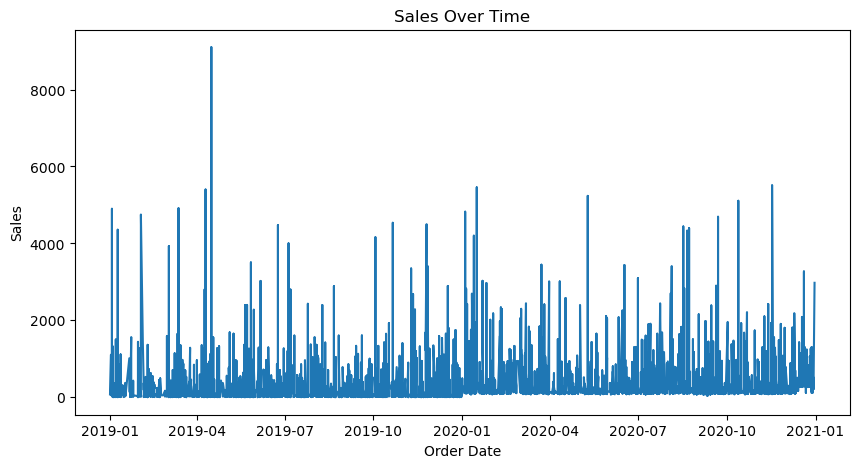

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df['Order Date'],df['Sales'])
plt.title("Sales Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.savefig("Sales_over_time.png",dpi=300,bbox_inches="tight")
plt.show()

In [12]:
df['Days']=(df['Order Date']-df['Order Date'].min()).dt.days

In [13]:
X=df[['Days']]
y=df['Sales']

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred=model.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error,r2_score
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("R2 Score:",r2_score(y_test,y_pred))

Mean Absolute Error: 232.04390277106177
R2 Score: 0.012720810044017372


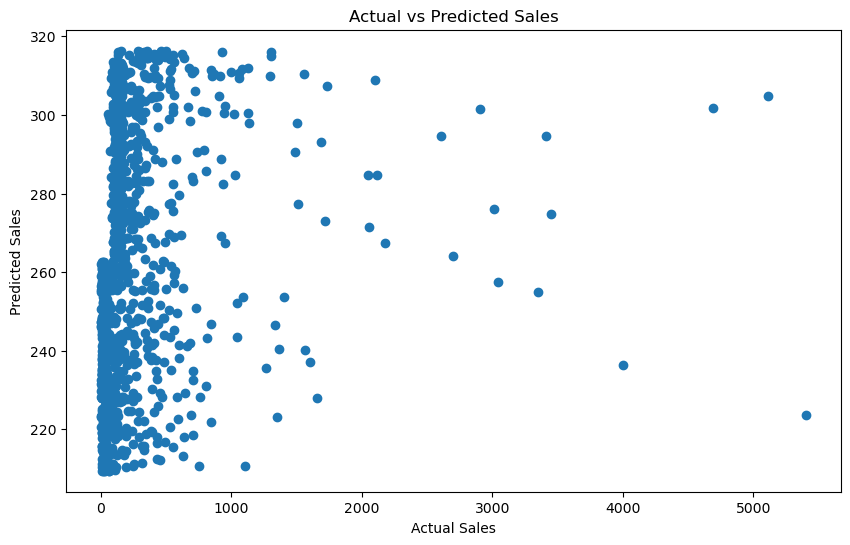

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.savefig("Actual_vs_Predicted.png",dpi=300,bbox_inches="tight")
plt.show()

In [20]:
results=pd.DataFrame({'Actual Sales':y_test,'Predicted Sales':y_pred})
results.to_csv("Predicted_Sales.csv",index=False)
results.head()

,Actual Sales,Predicted Sales
3233,107.760,279.383986
5306,125.600,310.436152
4412,114.360,308.817319
2651,160.984,264.814486
5024,110.688,273.055820
